<a href="https://colab.research.google.com/github/Anjali2000702/CP-Lab/blob/main/CPL3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numba import cuda, float32
import math

# CUDA kernel
@cuda.jit
def matmul_kernel(A, B, C):
    row, col = cuda.grid(2)

    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.0
        for k in range(A.shape[1]):
            tmp += A[row, k] * B[k, col]
        C[row, col] = tmp


# Main function
def cuda_matmul(A, B):
    # Matrix sizes
    m, k = A.shape
    k2, n = B.shape

    assert k == k2, "Matrix dimensions do not match"

    # Allocate output
    C = np.zeros((m, n), dtype=np.float32)

    # Copy to device (GPU)
    d_A = cuda.to_device(A)
    d_B = cuda.to_device(B)
    d_C = cuda.to_device(C)

    # Thread/block configuration
    threads_per_block = (16, 16)
    blocks_per_grid_x = math.ceil(m / threads_per_block[0])
    blocks_per_grid_y = math.ceil(n / threads_per_block[1])

    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # Launch kernel
    matmul_kernel[blocks_per_grid, threads_per_block](d_A, d_B, d_C)

    # Copy back to host (CPU)
    d_C.copy_to_host(C)

    return C


# Test
if __name__ == "__main__":

    # Create random matrices
    A = np.random.rand(512, 512).astype(np.float32)
    B = np.random.rand(512, 512).astype(np.float32)

    # GPU multiplication
    C_gpu = cuda_matmul(A, B)

    # CPU multiplication (for verification)
    C_cpu = np.dot(A, B)

    # Compare
    error = np.max(np.abs(C_gpu - C_cpu))
    print("Max error:", error)


Max error: 9.1552734e-05


In [ ]:
import numpy as np
from numba import cuda
import math


# CUDA Kernel
@cuda.jit
def matmul_kernel(A, B, C):
    row, col = cuda.grid(2)

    if row < C.shape[0] and col < C.shape[1]:
        temp = 0.0
        for k in range(A.shape[1]):
            temp += A[row, k] * B[k, col]
        C[row, col] = temp


# GPU Function
def cuda_matmul(A, B):

    m, k = A.shape
    k2, n = B.shape

    assert k == k2

    C = np.zeros((m, n), dtype=np.float32)

    # Copy to GPU
    d_A = cuda.to_device(A)
    d_B = cuda.to_device(B)
    d_C = cuda.to_device(C)

    # Threads & Blocks
    threads = (16, 16)
    blocks_x = math.ceil(m / threads[0])
    blocks_y = math.ceil(n / threads[1])

    blocks = (blocks_x, blocks_y)

    # Run Kernel
    matmul_kernel[blocks, threads](d_A, d_B, d_C)

    # Copy back
    d_C.copy_to_host(C)

    return C


# Test
if __name__ == "__main__":

    A = np.random.rand(512, 512).astype(np.float32)
    B = np.random.rand(512, 512).astype(np.float32)

    print("Running on GPU...")

    C_gpu = cuda_matmul(A, B)

    print("Running on CPU...")
    C_cpu = np.dot(A, B)

    error = np.max(np.abs(C_gpu - C_cpu))

    print("Max Error:", error)


Running on GPU...
Running on CPU...
Max Error: 9.918213e-05


Image Information:
Height : 2100
Width  : 4480
Channels : 3

Execution Time:
CPU Time : 0.11458921432495117 seconds
GPU Time : 0.6758670806884766 seconds


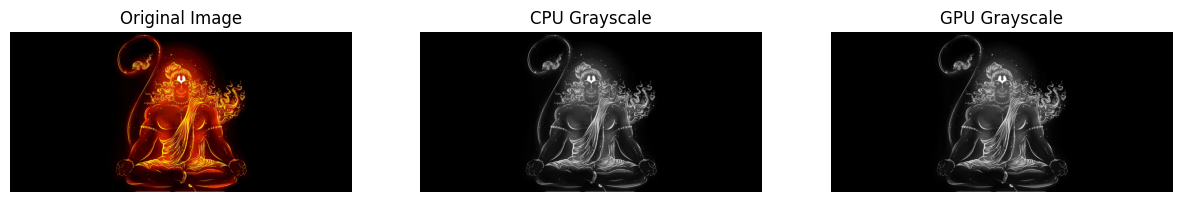

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import cupy as cp


# Load Image
img_name = list(uploaded.keys())[0]
image = cv2.imread(img_name)

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# Show Image Info
height, width, channels = image.shape

print("Image Information:")
print("Height :", height)
print("Width  :", width)
print("Channels :", channels)


# ---------------- CPU GRAYSCALE ----------------

start_cpu = time.time()

R = image[:,:,0]
G = image[:,:,1]
B = image[:,:,2]

gray_cpu = 0.299*R + 0.587*G + 0.114*B
gray_cpu = gray_cpu.astype(np.uint8)

end_cpu = time.time()

cpu_time = end_cpu - start_cpu


# ---------------- GPU GRAYSCALE ----------------

# Send to GPU
gpu_img = cp.asarray(image)

start_gpu = time.time()

R_gpu = gpu_img[:,:,0]
G_gpu = gpu_img[:,:,1]
B_gpu = gpu_img[:,:,2]

gray_gpu = 0.299*R_gpu + 0.587*G_gpu + 0.114*B_gpu

# Back to CPU
gray_gpu = cp.asnumpy(gray_gpu).astype(np.uint8)

end_gpu = time.time()

gpu_time = end_gpu - start_gpu


# ---------------- SHOW RESULTS ----------------

print("\nExecution Time:")
print("CPU Time :", cpu_time, "seconds")
print("GPU Time :", gpu_time, "seconds")


# Display Images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("CPU Grayscale")
plt.imshow(gray_cpu, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("GPU Grayscale")
plt.imshow(gray_gpu, cmap="gray")
plt.axis("off")

plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving wp14713676.jpg to wp14713676 (1).jpg


Image Information:
Height  : 2100
Width   : 4480
Channels: 3

Execution Time:
CPU Time : 0.10817575454711914 seconds
GPU Time : 0.003930568695068359 seconds


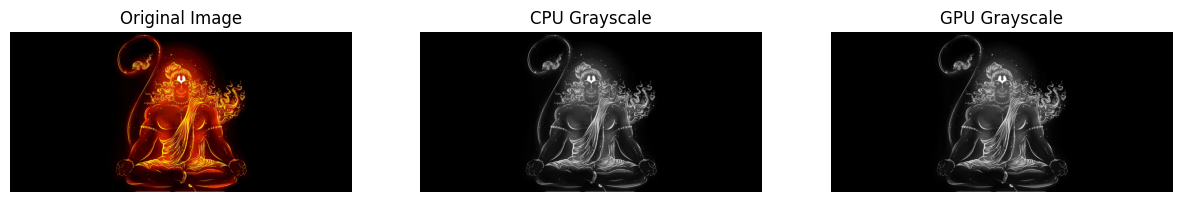

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import cupy as cp


# ---------------- LOAD IMAGE ----------------

img_name = list(uploaded.keys())[0]

image = cv2.imread(img_name)

# BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ---------------- IMAGE INFO ----------------

height, width, channels = image.shape

print("Image Information:")
print("Height  :", height)
print("Width   :", width)
print("Channels:", channels)


# ---------------- CPU GRAYSCALE ----------------

start_cpu = time.time()

R = image[:,:,0]
G = image[:,:,1]
B = image[:,:,2]

gray_cpu = 0.299*R + 0.587*G + 0.114*B
gray_cpu = gray_cpu.astype(np.uint8)

end_cpu = time.time()

cpu_time = end_cpu - start_cpu


# ---------------- GPU GRAYSCALE ----------------

# Copy to GPU
gpu_img = cp.asarray(image)

# Sync before timing
cp.cuda.Stream.null.synchronize()

start_gpu = time.time()

R_gpu = gpu_img[:,:,0]
G_gpu = gpu_img[:,:,1]
B_gpu = gpu_img[:,:,2]

gray_gpu = 0.299*R_gpu + 0.587*G_gpu + 0.114*B_gpu

# Sync after computation
cp.cuda.Stream.null.synchronize()

end_gpu = time.time()

# Back to CPU
gray_gpu = cp.asnumpy(gray_gpu).astype(np.uint8)

gpu_time = end_gpu - start_gpu


# ---------------- TIME RESULT ----------------

print("\nExecution Time:")
print("CPU Time :", cpu_time, "seconds")
print("GPU Time :", gpu_time, "seconds")


# ---------------- DISPLAY ----------------

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("CPU Grayscale")
plt.imshow(gray_cpu, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("GPU Grayscale")
plt.imshow(gray_gpu, cmap="gray")
plt.axis("off")

plt.show()
